In [55]:
targetPath = "/home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-25_12-17"
recursive = False

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

results = pd.read_parquet(targetPath + "/test1.parquet")

In [57]:
def renameQMINstate(state):
    match state:
        case -1:
            return "No Answer (e.g Timeout, Refused, ...)"
        case 0:
            return "No QMIN"
        case 1:
            return "QMIN"
        case 2:
            return "Both QMIN and NO QMIN observed"
        case _:
            return "Wrong QMIN state"

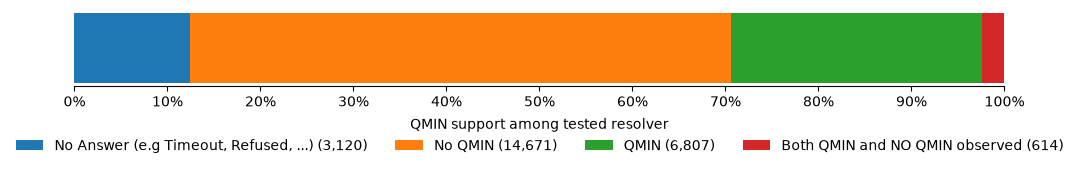

In [58]:
qmin_stat = results.groupby("qmin_enabled").agg(total=("qmin_enabled", "count"))
counts = qmin_stat["total"]
perc = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(12,1))

left = 0
for label, val in perc.items():
    ax.barh(y=0, width=val,left=left, height=0.5, label=f"{renameQMINstate(label)} ({counts[label]:,})")
    left+=val

# percentage steps
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 10)])

# remove y-axis
ax.set_yticks([])

# remove chart borders
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)

# adding legend
ax.legend(
    title="QMIN support among tested resolver",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)

plt.show()

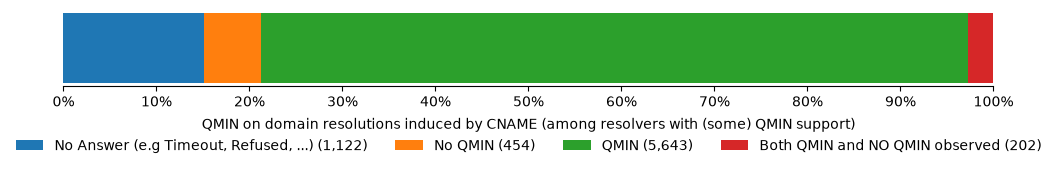

In [59]:
qmin_stat = results[results["qmin_enabled"] >= 1].groupby("induction_qmin").agg(total=("induction_qmin", "count"))
counts = qmin_stat["total"]
perc = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(12,1))

left = 0
for label, val in perc.items():
    ax.barh(y=0, width=val,left=left, height=0.5, label=f"{renameQMINstate(label)} ({counts[label]:,})")
    left+=val

# percentage steps
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 10)])

# remove y-axis
ax.set_yticks([])

# remove chart borders
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)

# adding legend
ax.legend(
    title="QMIN on domain resolutions induced by CNAME (among resolvers with (some) QMIN support)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)

plt.show()

In [60]:
test = results[results["qmin_enabled"] == 0].groupby("induction_qmin").agg(total=("induction_qmin", "count"))
print(test)

                total
induction_qmin       
-1                171
 0              14483
 1                 10
 2                  7


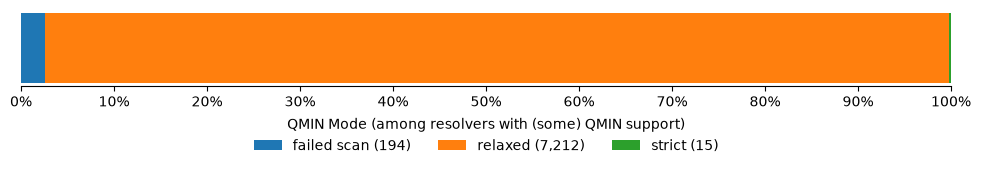

In [61]:
qmin_mode = results[results["qmin_enabled"] >= 1].groupby("qmin_mode").agg(total=("qmin_mode", "count"))
counts = qmin_mode["total"]
perc = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(12,1))

left = 0
for label, val in perc.items():
    ax.barh(y=0, width=val,left=left, height=0.5, label=f"{"failed scan" if label == "" else label} ({counts[label]:,})")
    left+=val

# percentage steps
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 10)])

# remove y-axis
ax.set_yticks([])

# remove chart borders
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)

# adding legend
ax.legend(
    title="QMIN Mode (among resolvers with (some) QMIN support)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)

plt.show()

In [63]:
qmin_mode = results[results["qmin_enabled"] == 0].groupby("qmin_mode").agg(total=("qmin_mode", "count"))
print(qmin_mode)

           total
qmin_mode       
           14562
relaxed      109


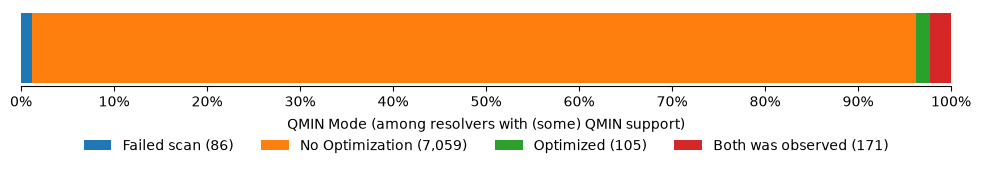

In [ ]:
nxop = results[results["qmin_enabled"] >= 1].groupby("nx_optimization").agg(total=("nx_optimization", "count"))
counts = nxop["total"]
perc = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(12,1))

def renameNXState(state):
    match state:
        case -1:
            return "failed scan"
        case 0:
            return "No Optimization"
        case 1: 
            return "Optimized"
        case 2:
            return "Both was observed"


left = 0
for label, val in perc.items():
    ax.barh(y=0, width=val,left=left, height=0.5, label=f"{renameNXState(label)} ({counts[label]:,})")
    left+=val

# percentage steps
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 10)])

# remove y-axis
ax.set_yticks([])

# remove chart borders
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)

# adding legend
ax.legend(
    title="NXDOMAIN optimization (among resolvers with (some) QMIN support)",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=4,
    frameon=False
)

plt.show()